In [1]:
from google.colab import files
uploaded = files.upload()

Saving BostonHousing - BostonHousing.csv to BostonHousing - BostonHousing.csv


Q1. What is Machine Learning? Explain the main types of Machine Learning with examples.

Machine Learning (ML) is a branch of Artificial Intelligence (AI) that enables computers to learn patterns from data and make predictions or decisions without being explicitly programmed.

Main Types of Machine Learning
1. Supervised Learning

The model learns from labeled data (input and correct output are provided).

Examples:

Predicting house prices using past housing data.
Email spam detection.
Student result prediction.
2. Unsupervised Learning

The model learns from unlabeled data and identifies hidden patterns or groups.

Examples:

Customer segmentation.
Market basket analysis.
Grouping similar news articles.
3. Reinforcement Learning

The model learns through rewards and penalties by interacting with an environment.

Examples:

Self-driving cars.
Game-playing AI (Chess, Go).
Robot navigation.
Q2. What is Supervised Learning? Explain the difference between Regression and Classification.
Supervised Learning

Supervised Learning is a Machine Learning technique where the model is trained using labeled data, meaning both input features and corresponding output values are available.

Example:
Using past sales data to predict future sales.

Difference Between Regression and Classification
Feature	Regression	Classification
Output Type	Continuous value	Categorical value
Goal	Predict numerical values	Predict classes/categories
Example	House price prediction	Spam or Not Spam
Output	₹25,00,000	Spam / Not Spam
Algorithms	Linear Regression	Logistic Regression, Decision Tree
Examples

Regression: Predicting employee salary based on experience.

Classification: Predicting whether a customer will buy a product (Yes/No).

Q3. What is Linear Regression? Write the Linear Regression equation and explain intercept and coefficient.
Linear Regression

Linear Regression is a supervised learning algorithm used to predict a continuous target variable by establishing a linear relationship between independent and dependent variables.

Equation of Linear Regression
Y=β
0
	​

+β
1
	​

X+ϵ

Where:

Y = Dependent variable (target)
X = Independent variable (feature)
β₀ = Intercept
β₁ = Coefficient (slope)
ε = Error term
Intercept (β₀)

The intercept is the predicted value of Y when X = 0.

Example:

Salary=20,000+5,000×Experience

Here, ₹20,000 is the salary when experience is 0 years.

Coefficient (β₁)

The coefficient indicates how much Y changes for a one-unit increase in X.

In the above example:

Coefficient = 5,000
For every additional year of experience, salary increases by ₹5,000.

Q4. Explain the following evaluation metrics used in Linear Regression.
1. SSE (Sum of Squared Errors)

Measures the total squared difference between actual and predicted values.

Formula
SSE=∑(Y
i
	​

−
Y
i
	​

^
	​

)
2

Where:

Y
i
	​

 = Actual value
Y
i
	​

^
	​

 = Predicted value

Interpretation:

Lower SSE indicates a better model.
SSE = 0 means perfect prediction.
2. MSE (Mean Squared Error)

Average of squared prediction errors.

Formula
MSE=
n
∑(Y
i
	​

−
Y
i
	​

^
	​

)
2
	​


Where:

n = Number of observations

Interpretation:

Lower MSE indicates better model performance.
Penalizes large errors heavily.
3. RMSE (Root Mean Squared Error)

Square root of MSE.

Formula
RMSE=
MSE
	​


Interpretation:

Measures average prediction error.
Expressed in the same units as the target variable.
Easier to interpret than MSE.
4. R² Score (Coefficient of Determination)

Measures how much variance in the target variable is explained by the model.

Formula
R
2
=1−
SST
SSE
	​


Where:

SSE = Sum of Squared Errors
SST = Total Sum of Squares

Interpretation:

R² = 1 → Perfect fit
R² = 0 → Model explains no variance
Higher R² is better

Example:
R² = 0.85 means the model explains 85% of the variation in the data.

5. Adjusted R²

Adjusted R² improves R² by considering the number of predictors in the model.

Formula
Adjusted R
2
=1−(
n−p−1
(1−R
2
)(n−1)
	​

)

Where:

n = Number of observations
p = Number of independent variables

Interpretation:

Penalizes unnecessary features.
Useful for Multiple Linear Regression.
Higher Adjusted R² indicates a better model.

Q5. Explain the Machine Learning workflow steps from data collection to model evaluation.
Step 1: Data Collection

Gather data from various sources such as:

Databases
APIs
CSV files
Surveys
Sensors
Step 2: Data Understanding

Analyze the dataset to understand:

Data types
Missing values
Outliers
Feature distributions
Step 3: Data Preprocessing

Clean and prepare the data:

Handle missing values
Remove duplicates
Treat outliers
Encode categorical variables
Scale numerical features
Step 4: Exploratory Data Analysis (EDA)

Visualize and analyze data patterns using:

Histograms
Box plots
Scatter plots
Correlation heatmaps
Step 5: Feature Engineering

Create or transform features to improve model performance.

Examples:

Age groups from age values
Extracting year from date columns
Step 6: Train-Test Split

Split data into:

Training Set (typically 70–80%)
Testing Set (typically 20–30%)
Step 7: Model Selection

Choose a suitable algorithm based on the problem.

Examples:

Linear Regression for regression tasks
Logistic Regression for classification tasks
Step 8: Model Training

Train the selected model using the training dataset.

Step 9: Model Prediction

Use the trained model to make predictions on test data.

Step 10: Model Evaluation

Evaluate performance using appropriate metrics.

For Regression:

SSE
MSE
RMSE
R² Score
Adjusted R²

For Classification:

Accuracy
Precision
Recall
F1-Score
Step 11: Model Deployment (Optional)

Deploy the model into production for real-world use.

Step 12: Monitoring and Maintenance

Continuously monitor model performance and retrain when necessary.

In [3]:
# Importing Libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [4]:
df = pd.read_csv("/content/BostonHousing - BostonHousing.csv")
df.head()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
0,0.00632,18.0,2.31,0,0.538,6.575,65.2,4.0900,1,296,15.3,396.90,4.98,24.0
1,0.02731,0.0,7.07,0,0.469,6.421,78.9,4.9671,2,242,17.8,396.90,9.14,21.6
2,0.02729,0.0,7.07,0,0.469,7.185,61.1,4.9671,2,242,17.8,392.83,4.03,34.7
3,0.03237,0.0,2.18,0,0.458,6.998,45.8,6.0622,3,222,18.7,394.63,2.94,33.4
4,0.06905,0.0,2.18,0,0.458,7.147,54.2,6.0622,3,222,18.7,396.90,5.33,36.2


In [5]:
df.tail()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
501,0.06263,0.0,11.93,0,0.573,6.593,69.1,2.4786,1,273,21.0,391.99,9.67,22.4
502,0.04527,0.0,11.93,0,0.573,6.120,76.7,2.2875,1,273,21.0,396.90,9.08,20.6
503,0.06076,0.0,11.93,0,0.573,6.976,91.0,2.1675,1,273,21.0,396.90,5.64,23.9
504,0.10959,0.0,11.93,0,0.573,6.794,89.3,2.3889,1,273,21.0,393.45,6.48,22.0
505,0.04741,0.0,11.93,0,0.573,6.030,80.8,2.5050,1,273,21.0,396.90,7.88,11.9


In [6]:
df.columns

Index(['crim', 'zn', 'indus', 'chas', 'nox', 'rm', 'age', 'dis', 'rad', 'tax',
       'ptratio', 'b', 'lstat', 'medv'],
      dtype='object')

In [7]:
df.shape

(506, 14)

In [8]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 506 entries, 0 to 505
Data columns (total 14 columns):
 #   Column   Non-Null Count  Dtype  
---  ------   --------------  -----  
 0   crim     506 non-null    float64
 1   zn       506 non-null    float64
 2   indus    506 non-null    float64
 3   chas     506 non-null    int64  
 4   nox      506 non-null    float64
 5   rm       506 non-null    float64
 6   age      506 non-null    float64
 7   dis      506 non-null    float64
 8   rad      506 non-null    int64  
 9   tax      506 non-null    int64  
 10  ptratio  506 non-null    float64
 11  b        506 non-null    float64
 12  lstat    506 non-null    float64
 13  medv     506 non-null    float64
dtypes: float64(11), int64(3)
memory usage: 55.5 KB


In [9]:
df.describe()

,crim,zn,indus,chas,nox,rm,age,dis,rad,tax,ptratio,b,lstat,medv
count,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000,506.000000
mean,3.613524,11.363636,11.136779,0.069170,0.554695,6.284634,68.574901,3.795043,9.549407,408.237154,18.455534,356.674032,12.653063,22.532806
std,8.601545,23.322453,6.860353,0.253994,0.115878,0.702617,28.148861,2.105710,8.707259,168.537116,2.164946,91.294864,7.141062,9.197104
min,0.006320,0.000000,0.460000,0.000000,0.385000,3.561000,2.900000,1.129600,1.000000,187.000000,12.600000,0.320000,1.730000,5.000000
25%,0.082045,0.000000,5.190000,0.000000,0.449000,5.885500,45.025000,2.100175,4.000000,279.000000,17.400000,375.377500,6.950000,17.025000
50%,0.256510,0.000000,9.690000,0.000000,0.538000,6.208500,77.500000,3.207450,5.000000,330.000000,19.050000,391.440000,11.360000,21.200000
75%,3.677083,12.500000,18.100000,0.000000,0.624000,6.623500,94.075000,5.188425,24.000000,666.000000,20.200000,396.225000,16.955000,25.000000
max,88.976200,100.000000,27.740000,1.000000,0.871000,8.780000,100.000000,12.126500,24.000000,711.000000,22.000000,396.900000,37.970000,50.000000


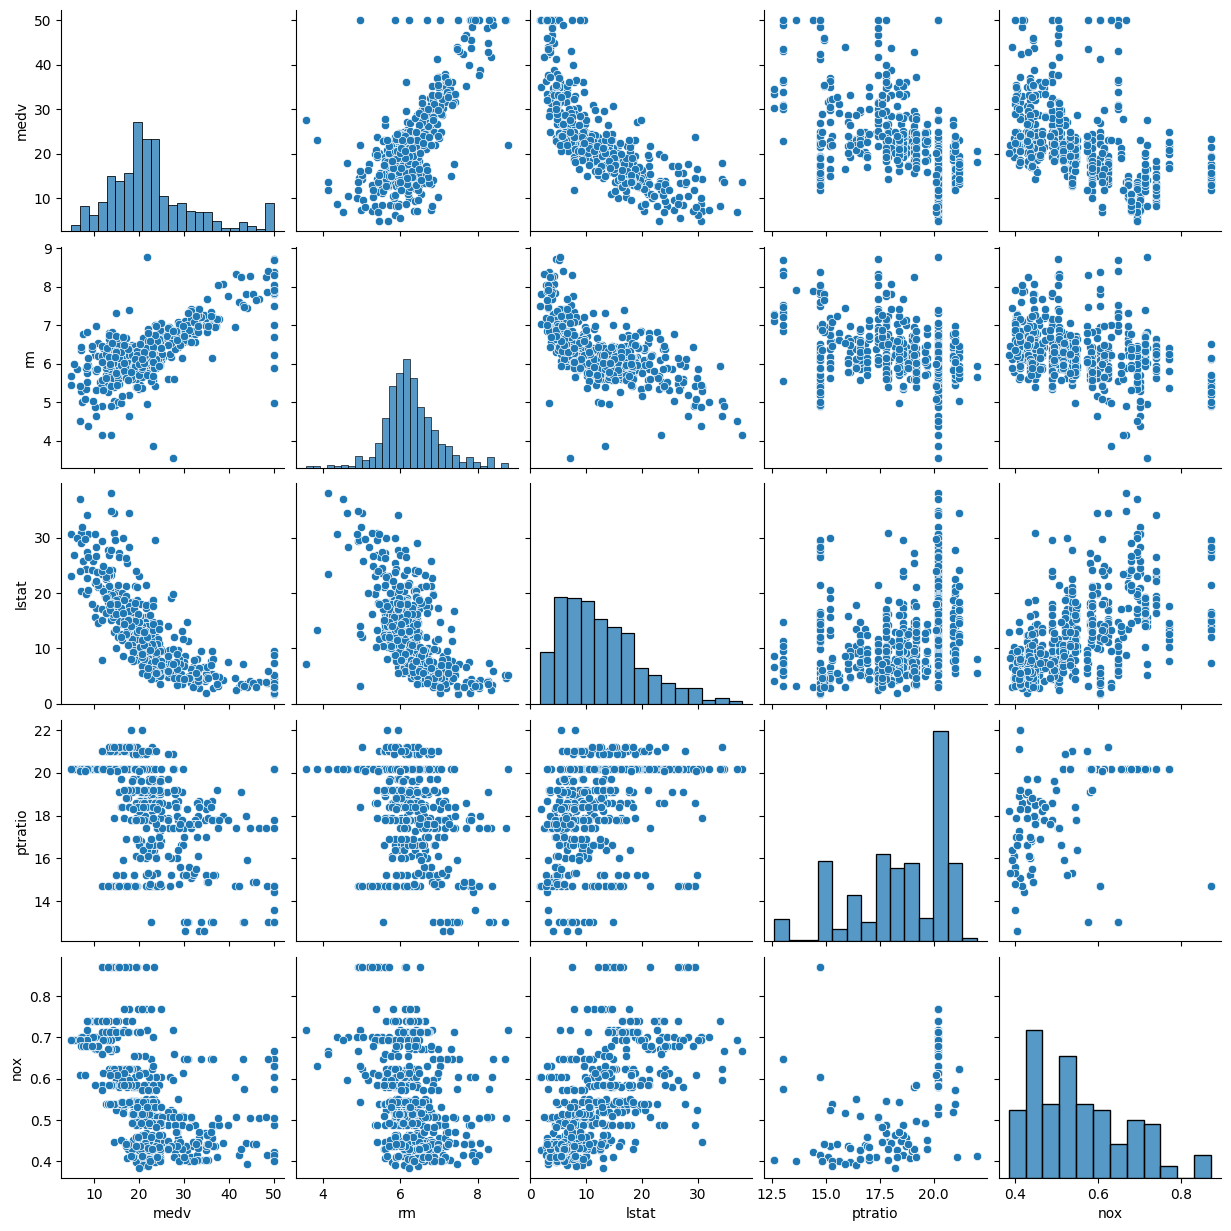

In [10]:
# Creating Pairplot
sns.pairplot(df[['medv','rm','lstat','ptratio','nox']])
plt.show()

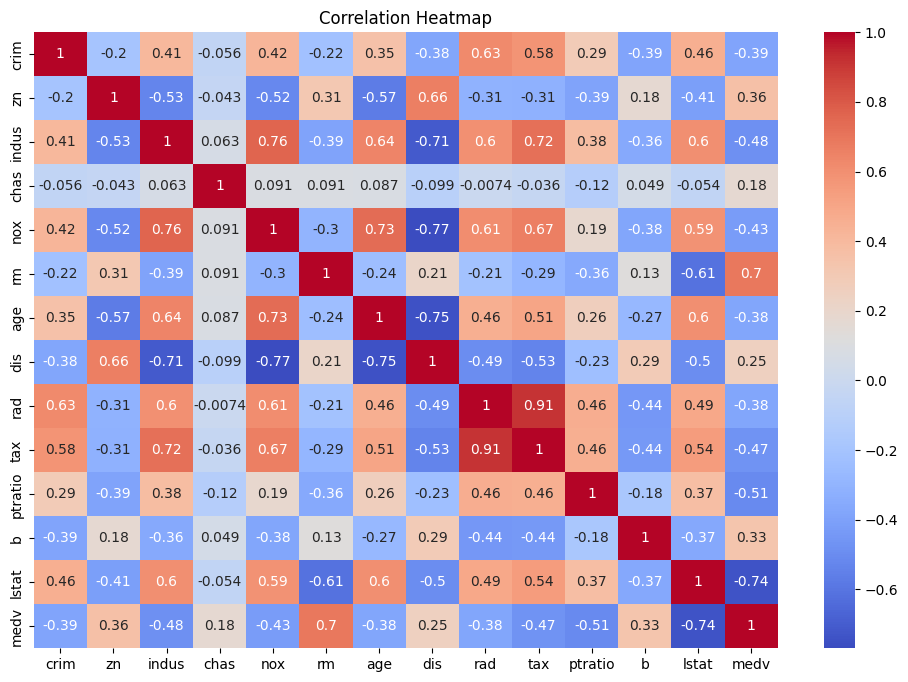

In [11]:
# Creating Correlation Heatmap
plt.figure(figsize=(12,8))
sns.heatmap(df.corr(), annot=True, cmap='coolwarm')
plt.title("Correlation Heatmap")
plt.show()

Identify which features are highly correlated with house price (medv)

| Feature | Correlation with medv |
| ------- | --------------------- |
| rm      | +0.695                |
| lstat   | -0.738                |
| ptratio | -0.508                |
| indus   | -0.484                |
| tax     | -0.469                |
| nox     | -0.427                |
| crim    | -0.388                |


In [12]:
# Select independent variables (features) and dependent variables (target)

# Target Variables
y = df['medv']

# Feature Variables
x = df.drop('medv', axis=1)


In [15]:
# Split dataset into training and testing sets (80% training, 20% Testing)

from sklearn.model_selection import train_test_split

x_train,x_test,y_train,y_test = train_test_split(x,y,
                                                 test_size = 0.20,
                                                 random_state=42
                                                 )

In [16]:
# Train Linear Regression Model and Evaluate

# Train the Model
from sklearn.linear_model import LinearRegression


model = LinearRegression()
model.fit(x_train, y_train)

LinearRegression()

In [19]:
# Make Prediction
y_pred = model.predict(x_test)

In [20]:
# Evaluate Metrics

# MAE
from sklearn.metrics import mean_absolute_error

mae = mean_absolute_error(y_test, y_pred)
print(mae)

3.189091965887837


In [21]:
# MSE
from sklearn.metrics import mean_squared_error

mse = mean_squared_error(y_test, y_pred)
print(mse)

24.291119474973478


In [22]:
# RMSE
import numpy as np

rmse = np.sqrt(mse)
print(rmse)

4.928602182665332


In [23]:
# R2 Score
from sklearn.metrics import r2_score

r2 = r2_score(y_test, y_pred)
print(r2)

0.6687594935356326


In [25]:
# Adjusted R2
n = x_test.shape[0]
p = x_test.shape[1]

adjusted_r2 = 1 - ((1-r2)*(n-1)/(n-p-1))
print(adjusted_r2)

0.619826236898851


Linear Regression Equation

The trained model equation is:

MEDV=30.2468−0.1131(CRIM)+0.0301(ZN)+0.0404(INDUS)+2.7844(CH


Interpretation of Model Coefficients
| Feature | Coefficient | Interpretation                                            |
| ------- | ----------- | --------------------------------------------------------- |
| crim    | -0.1131     | Higher crime rate decreases house price                   |
| zn      | +0.0301     | More residential land slightly increases price            |
| indus   | +0.0404     | Small positive impact                                     |
| chas    | +2.7844     | Houses near Charles River are more expensive              |
| nox     | -17.2026    | Higher pollution strongly reduces house price             |
| rm      | +4.4388     | Each additional room increases house price significantly  |
| age     | -0.0063     | Older houses slightly decrease price                      |
| dis     | -1.4479     | Greater distance from employment centers reduces price    |
| rad     | +0.2624     | Slight positive effect                                    |
| tax     | -0.0106     | Higher property tax lowers price                          |
| ptratio | -0.9155     | Higher student-teacher ratio lowers price                 |
| b       | +0.0124     | Small positive impact                                     |
| lstat   | -0.5086     | Higher lower-status population percentage decreases price |
